<a href="https://colab.research.google.com/github/AndrewDavidRatnam/HuggingFace_IntroToAudioCourse/blob/main/HF_AudioCourse_Unit_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notes:
- Resample the data to model specifications, as the attention mechanisims are trained with keeping sampling rates in mind.
- when you preprcoess correctly and visualize the waveform, you can intutively know if you have done the preprocessing correctly

In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np


# Introduction to Audio Data

In [195]:
array, sampling_rate = librosa.load(librosa.ex("trumpet"))

In [196]:
sampling_rate

22050

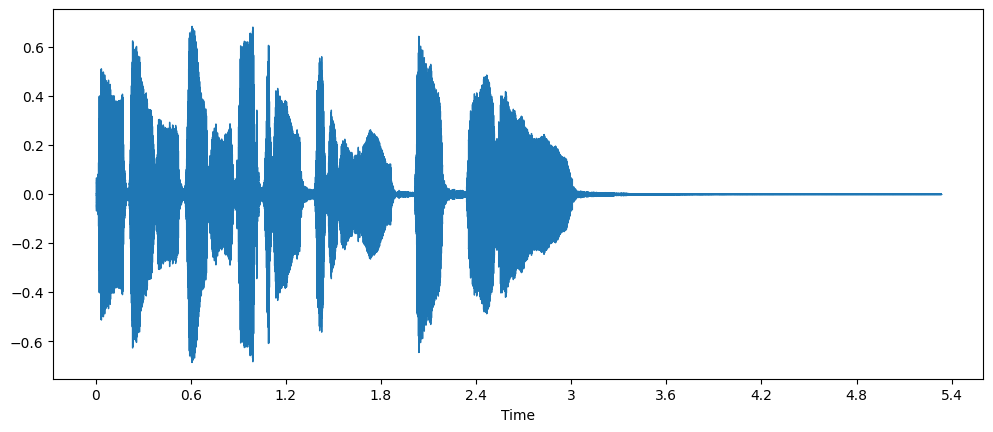

In [197]:

plt.figure().set_figwidth(12)
librosa.display.waveshow(array,sr=sampling_rate)
plt.show()

In [198]:
array.max(), array.min()

(np.float32(0.63159853), np.float32(-0.6847599))

### Let's DFT this shizz

In [199]:
len(array)/4096

28.711181640625

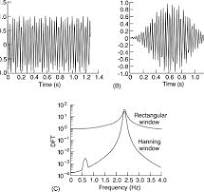

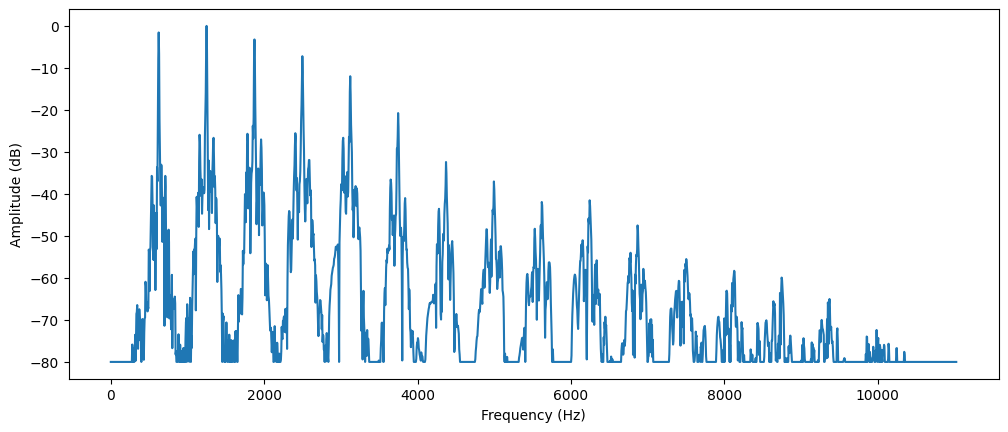

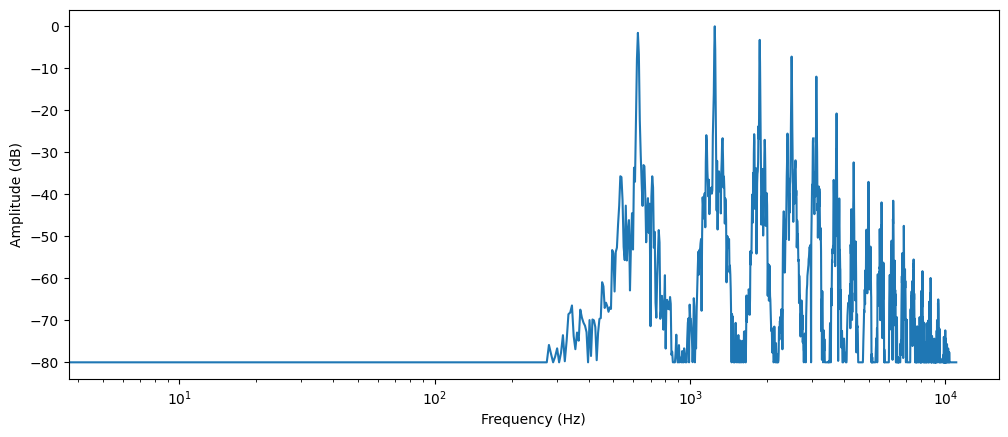

In [200]:
dft_input = array[:4096]

window = np.hanning(len(dft_input))
windowed_input = dft_input * window #claude caught this error
dft = np.fft.rfft(windowed_input)

amplitude = np.abs(dft)

amplitude_db = librosa.amplitude_to_db(amplitude,ref=np.max)

frequency =  librosa.fft_frequencies(sr=sampling_rate, n_fft=len(dft_input))


plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.show()
plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xscale("log")
plt.show()




### Spectogram

Multiple DFTs, each covering a small slice of time and stack the resulting spectra together into a spectogram

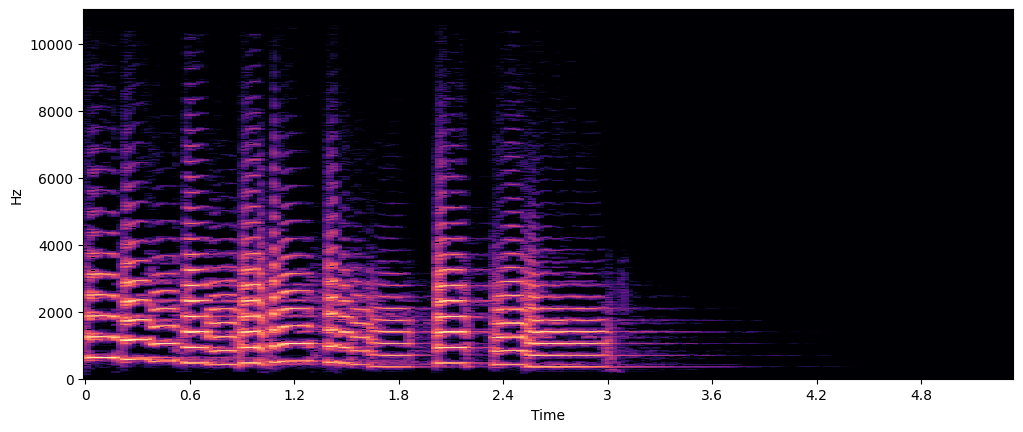

In [8]:
D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_db,x_axis="time",y_axis="hz")
plt.show()

In [9]:
D.shape,S_db.shape

((1025, 230), (1025, 230))

### Mel Spectogram

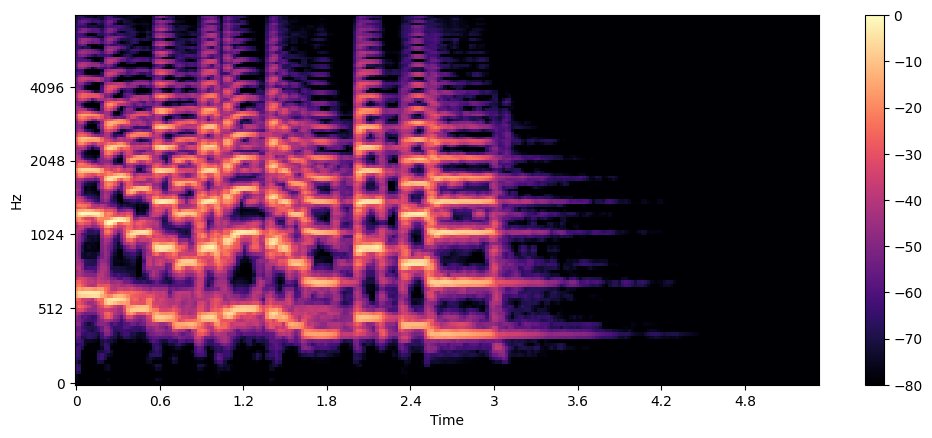

In [10]:
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sampling_rate, fmax=8000)
plt.colorbar()

# Load and explore an audio set

In [11]:
!pip install datasets[audio] soundfile librosa torchcodec

In [88]:
from datasets import load_dataset

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 654
})

In [89]:
example = minds[0]

In [90]:
example

{'path': 'en-AU~PAY_BILL/response_4.wav',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7ca8ae47e180>,
 'transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'english_transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'intent_class': 13,
 'lang_id': 2}

In [91]:
id2label = minds.features["intent_class"].int2str
id2label(example["intent_class"])

'pay_bill'

In [92]:
cols_to_remove = ["lang_id", "english_transcription"]
minds = minds.remove_columns(cols_to_remove)
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 654
})

In [93]:
import gradio as gr

def generate_audio():
  example = minds.shuffle()[0]
  audio = example["audio"]
  return(
      audio["sampling_rate"],
      audio["array"],
),id2label(example["intent_class"])

with gr.Blocks() as demo:
  with gr.Column():
    for _ in range(4):
      audio, label = generate_audio()
      output = gr.Audio(audio, label=label)
demo.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cbe938375a9bb017e3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://cbe938375a9bb017e3.gradio.live


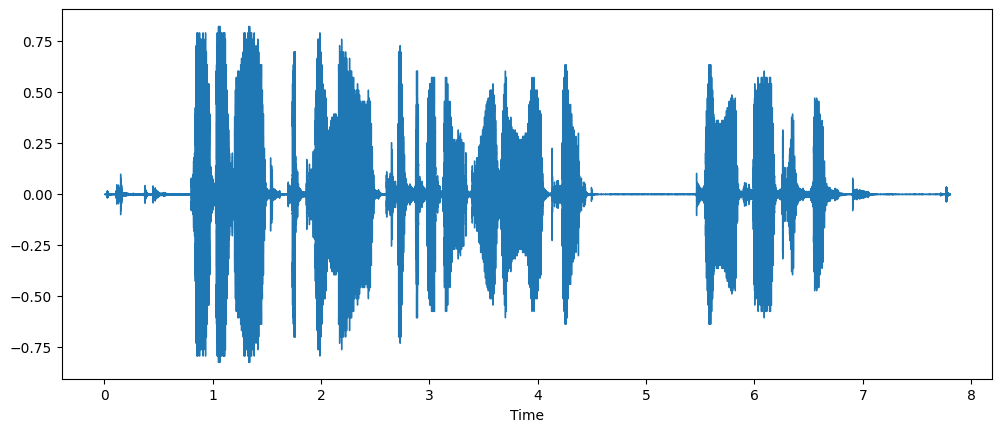

In [94]:
array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

# Preprocessing an audio dataset

We are going to the basic preprocessing steps

1.   Resample the audio data
2.   Filter the dataset
3.   Convert the audio data into model's expected input

Luckily HF has all this encapsulated, but we will also have to learn to do this manually


## Resampling the data

### HF Way

In [95]:
from datasets import Audio

In [96]:
minds_raw = minds.cast_column("audio", Audio(decode=False))
real_path = minds_raw[0]["audio"]["path"]
real_path

'response_4.wav'

In [97]:
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))
print(minds[0])
print(minds[0]["audio"].get_all_samples())
print(minds[0]["audio"].get_all_samples().data)

{'path': 'en-AU~PAY_BILL/response_4.wav', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7ca866e1e480>, 'transcription': 'I would like to pay my electricity bill using my card can you please assist', 'intent_class': 13}
AudioSamples:
  data (shape): torch.Size([1, 124830])
  pts_seconds: 0.0
  duration_seconds: 7.801875
  sample_rate: 16000

tensor([[0.0000, 0.0001, 0.0002,  ..., 0.0007, 0.0012, 0.0014]])


### Manual way

In [98]:
import torchaudio
import torchaudio.transforms as T

raw_bytes = minds_raw[0]["audio"]["bytes"]

waveform, orig_samp_rate = torchaudio.load(raw_bytes)
print(orig_samp_rate)

resampler = T.Resample(orig_samp_rate,16_000)
waveform_resamp = resampler(waveform)

8000


In [99]:
waveform_resamp.shape,waveform.shape

(torch.Size([1, 124830]), torch.Size([1, 62415]))

In [100]:
waveform_resamp.shape[1]/waveform.shape[1]

2.0

Some background on resampling: If an audio signal has been sampled at 8 kHz, so that it has 8000 sample readings per second, we know that the audio does not contain any frequencies over 4 kHz. This is guaranteed by the Nyquist sampling theorem. Because of this, we can be certain that in between the sampling points the original continuous signal always makes a smooth curve. Upsampling to a higher sampling rate is then a matter of calculating additional sample values that go in between the existing ones, by approximating this curve. Downsampling, however, requires that we first filter out any frequencies that would be higher than the new Nyquist limit, before estimating the new sample points. In other words, you can't downsample by a factor 2x by simply throwing away every other sample — this will create distortions in the signal called aliases. Doing resampling correctly is tricky and best left to well-tested libraries such as librosa or 🤗 Datasets.

## Filtering a Dataset

In [106]:
from copy import deepcopy

In [107]:
minds_copy = deepcopy(minds)

In [108]:
MAX_DURATION_SECONDS = 20.0

def is_audio_length_in_range(input_length):
  return input_length < MAX_DURATION_SECONDS



In [109]:
minds["audio"][0]["array"]

array([0.        , 0.00012415, 0.00024414, ..., 0.00071331, 0.0012207 ,
       0.00144803], dtype=float32)

In [110]:
new_column = [
    librosa.get_duration(y=x["array"], sr=x["sampling_rate"]) for x in minds["audio"]
]

In [111]:
minds = minds.add_column("duration", new_column)

In [112]:
minds = minds.filter(is_audio_length_in_range, input_columns=["duration"])

minds = minds.remove_columns(["duration"])
minds

Filter:   0%|          | 0/654 [00:00<?, ? examples/s]

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 624
})

### Torch manual

In [113]:
minds_copy

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 654
})

In [114]:
import torch
MAX_DURATION = 20.0

target_sr = 16_000

keep_indices = []

for i in range(len(minds_copy)):
  waveform = torch.tensor(minds_copy[i]["audio"]["array"])
  duration = waveform.shape[-1]/target_sr

  if duration < MAX_DURATION:
    keep_indices.append(i)

minds_filtered = minds_copy.select(keep_indices)

In [115]:
minds_filtered

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 624
})

## Pre-Processing Audio

In [116]:
from transformers import WhisperFeatureExtractor

In [117]:
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")

preprocessor_config.json: 0.00B [00:00, ?B/s]

In [118]:
def prepare_dataset(example):
  audio = example["audio"]

  if audio["sampling_rate"] != 16_000:
    audio_array = librosa.resample(
        audio["array"],
        orig_sr = audio["sampling_rate"],
        target_sr = 16_000
    )
    audio = {"array": audio_array,
             "sampling_rate": 16_000}

  features = feature_extractor(
      audio["array"],
      sampling_rate = audio["sampling_rate"],
      padding = True
  )
  return features



In [119]:
minds = minds.map(prepare_dataset)

Map:   0%|          | 0/624 [00:00<?, ? examples/s]

In [120]:
minds

Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class', 'input_features'],
    num_rows: 624
})

In [137]:
example = minds[0]
input_features = example["input_features"]

len(input_features[0]),len(input_features[0][0])

(80, 780)

In [139]:
feature_extractor.hop_length,feature_extractor.sampling_rate,

(160, 16000)

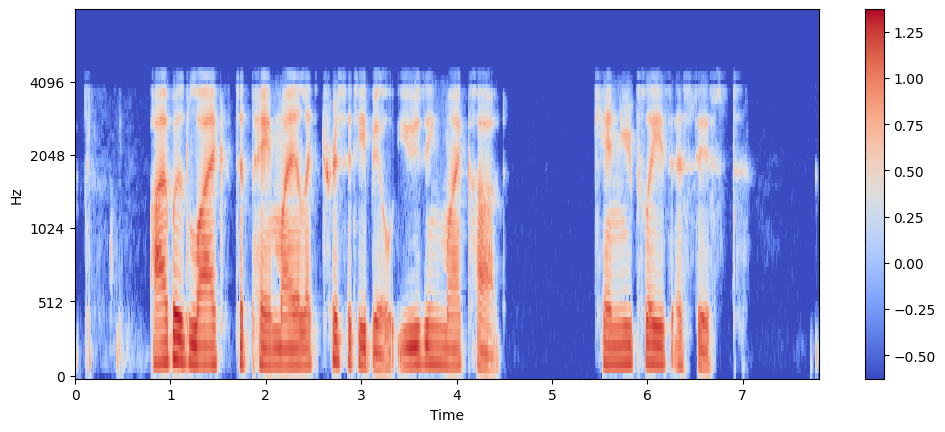

In [129]:

plt.figure().set_figwidth(12)
librosa.display.specshow(
    np.asarray(input_features[0]),
    x_axis="time",
    y_axis="mel",
    sr=feature_extractor.sampling_rate,
    hop_length=feature_extractor.hop_length,
)
plt.colorbar()

### Manual Way

In [164]:
import torch
import torchaudio
import torchaudio.transforms as T
import math

TARGET_SR = 16_000
N_FFT = 400
HOP_LENGTH = 160
N_MELS = 80
WINDOW_FN = torch.hann_window

MEL_TRANSFORM = T.MelSpectrogram(
      sample_rate = TARGET_SR,
      n_fft = N_FFT,
      hop_length = HOP_LENGTH,
      n_mels = N_MELS,
      window_fn = WINDOW_FN,
      power=2.0,
      center = True,
      pad_mode="reflect"
    )

FIXED_SAMPLES = 30 * TARGET_SR # 30 seconds x 16000 Hz or 1/seconds = 480,000 samples or datapoints

def manual_torch_whisper_prep(audio_array, orig_sr):
  waveform = torch.tensor(audio_array, dtype=torch.float32)

  if orig_sr != TARGET_SR:
    resampler = T.Resample(orig_sr, TARGET_SR)
    waveform = resampler(waveform)

  actual_samples = waveform.shape[-1]

  if actual_samples > FIXED_SAMPLES:
    waveform = waveform[:FIXED_SAMPLES]


  elif actual_samples < FIXED_SAMPLES:
    padding = FIXED_SAMPLES - actual_samples
    waveform = torch.nn.functional.pad(waveform,(0, padding))


  mel_spec = MEL_TRANSFORM(waveform)

  log_mel_spec = torch.log10(torch.clamp(mel_spec, min=1e-10))

  log_mel_spec = (log_mel_spec +4.0)/4.0

  return log_mel_spec

In [172]:
sample = minds_filtered[0]
raw_audio = sample["audio"]["array"]
sr = sample["audio"]["sampling_rate"]

torch_features = manual_torch_whisper_prep(raw_audio,sr)


In [173]:
torch_features.shape


torch.Size([80, 3001])

In [174]:
torch_features = torch_features[:,:780]

In [175]:
torch_features.shape

torch.Size([80, 780])

In [176]:
torch.tensor(input_features).shape

torch.Size([1, 80, 780])

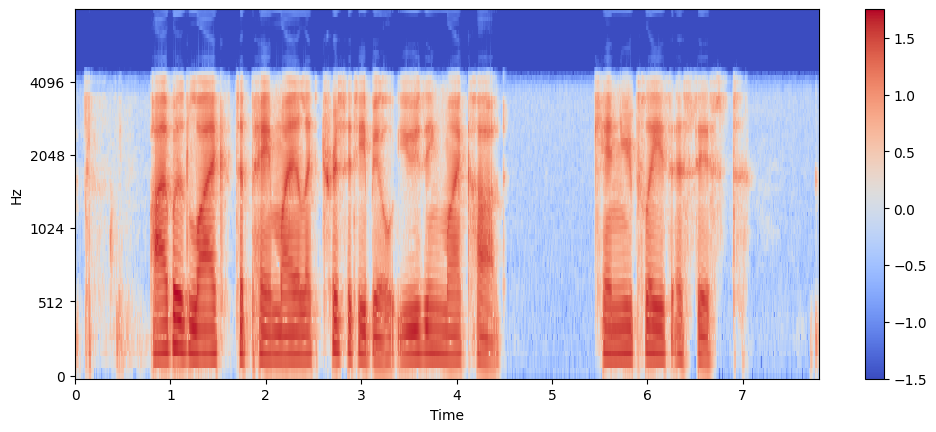

In [177]:
plt.figure().set_figwidth(12)
librosa.display.specshow(
    np.asarray(torch_features),
    x_axis="time",
    y_axis="mel",
    sr=feature_extractor.sampling_rate,
    hop_length=feature_extractor.hop_length,
)
plt.colorbar()

# Streaming Audio Data

In [180]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')

In [190]:
giga_speech = load_dataset("MLCommons/peoples_speech", "clean", streaming=True)

Resolving data files:   0%|          | 0/804 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/804 [00:00<?, ?it/s]

In [191]:
next(iter(giga_speech["train"]))

{'id': '07282016HFUUforum_SLASH_07-28-2016_HFUUforum_DOT_mp3_00000.flac',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7ca869317b60>,
 'duration_ms': 14920,
 'text': "i wanted this to share a few things but i'm going to not share as much as i wanted to share because we are starting late i'd like to get this thing going so we all get home at a decent hour this this election is very important to"}

In [192]:
giga_speech_head = giga_speech["train"].take(2)
list(giga_speech_head)

[{'id': '07282016HFUUforum_SLASH_07-28-2016_HFUUforum_DOT_mp3_00000.flac',
  'audio': <datasets.features._torchcodec.AudioDecoder at 0x7ca86932cf50>,
  'duration_ms': 14920,
  'text': "i wanted this to share a few things but i'm going to not share as much as i wanted to share because we are starting late i'd like to get this thing going so we all get home at a decent hour this this election is very important to"},
 {'id': '07282016HFUUforum_SLASH_07-28-2016_HFUUforum_DOT_mp3_00001.flac',
  'audio': <datasets.features._torchcodec.AudioDecoder at 0x7ca868d826c0>,
  'duration_ms': 14530,
  'text': "state we support agriculture to the tune of point four percent no way i made a mistake this year they lowered it from point four percent to point three eight percent and in the same breath they're saying food"}]

# Quiz Answers

1. **What units is the sampling rate measured in?**
  <br> **Hz**

2. **When streaming a large audio dataset, how soon can you start using it?**
   <br>**As soon as the first example is downloaded.**

3. **What is a spectrogram?**
   <br>**A visual representation of the frequency spectrum of a signal as it varies with time.**

4. **What is the easiest way to convert raw audio data into log-mel spectrogram expected by Whisper?**
   <br>
   
   ```python
   feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
   feature_extractor(audio["array"])
   ```

5. **How do you load a dataset from 🤗 Hub?**
   <br>

   ```python
   from datasets import load_dataset
   dataset = load_dataset(DATASET_NAME_ON_HUB)
   ```

6. **Your custom dataset contains high-quality audio with 32 kHz sampling rate. You want to train a speech recognition model that expects the audio examples to have a 16 kHz sampling rate. What should you do?**
   <br>**Use Audio module from the 🤗 Datasets library to downsample the examples in the custom dataset.**

7. **How can you convert a spectrogram generated by a machine learning model into a waveform?**
   <br>**We can use a neural network called a vocoder to reconstruct a waveform from the spectrogram.**


# 📚 HF Audio Course – Unit 1: Study Report

---

## 🗂️ Topics Covered

1. Introduction to Audio Data (Waveforms, Sampling, DFT)
2. Spectrograms (STFT & Mel Spectrogram)
3. Loading & Exploring Audio Datasets (🤗 Hub)
4. Preprocessing Audio Data (Resampling, Filtering, Feature Extraction)
5. Streaming Audio Datasets

---

## 1. 🎵 Introduction to Audio Data

### What is a waveform?
- Audio is represented as a **1D array of amplitude values** over time.
- Loaded using `librosa.load()` which returns `(array, sampling_rate)`.
- Visualized using `librosa.display.waveshow()`.

### Sampling Rate
- Measured in **Hz** (samples per second).
- A 22050 Hz signal has 22,050 amplitude readings per second.
- **Nyquist Theorem**: A signal sampled at `sr` Hz can only faithfully represent frequencies up to `sr/2` Hz.
```python
array, sampling_rate = librosa.load(librosa.ex("trumpet"))
# array.max(), array.min() → amplitude range, usually [-1.0, 1.0]
```

---

## 2. 📊 Frequency Analysis & Spectrograms

### Discrete Fourier Transform (DFT)
- Converts a time-domain signal into its **frequency components**.
- Shows which frequencies are present and at what amplitude (in dB).
- A **windowing function** (e.g., Hanning) is applied before DFT to reduce edge artifacts.
```python
window = np.hanning(len(dft_input))
windowed_input = dft_input * window   # Note: multiply, not add
dft = np.fft.rfft(windowed_input)
amplitude_db = librosa.amplitude_to_db(np.abs(dft), ref=np.max)
```

> ⚠️ **Note from code**: The notebook used `+` instead of `*` when applying the window — the correct operation is **multiplication** (`dft_input * window`).

### Spectrogram (STFT)
- Multiple DFTs computed over **short overlapping time windows**, stacked together.
- Gives a **2D view**: time on x-axis, frequency on y-axis, amplitude as color.
- Computed using `librosa.stft()`.
```python
D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
```

### Mel Spectrogram
- A spectrogram where the frequency axis is warped to the **Mel scale** — mimicking how humans perceive pitch (logarithmically).
- Used as input to most audio ML models including Whisper.
```python
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
```

---

## 3. 🗃️ Loading & Exploring Audio Datasets

### Loading from 🤗 Hub
```python
from datasets import load_dataset
minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
```

### Exploring a Dataset
- Access an example: `minds[0]`
- Label decoding: `minds.features["intent_class"].int2str`
- Remove unused columns: `minds.remove_columns(["lang_id", "english_transcription"])`

### Audio example structure
Each audio example contains:
- `array` → numpy array of amplitudes
- `sampling_rate` → integer (e.g., 8000 Hz)
- `path` → file path

### Visualizing with Gradio
- Use `gr.Audio()` to listen to audio examples interactively in Colab.

---

## 4. 🔧 Preprocessing Audio Data

### Step 1: Resampling

Models expect a **fixed sampling rate** (Whisper expects **16,000 Hz**).
Always resample to match the model's expected rate.

#### 🤗 HF Way (recommended):
```python
from datasets import Audio
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))
```

#### Manual Way (torchaudio):
```python
resampler = T.Resample(orig_samp_rate, 16_000)
waveform_resamp = resampler(waveform)
```

> ⚠️ **Important**: Never downsample by simply throwing away every other sample. This creates **aliasing distortions**. Always use a proper library (librosa, torchaudio, or 🤗 Datasets).

---

### Step 2: Filtering the Dataset

Filter out audio that is too long (or too short) for your model.

#### 🤗 HF Way:
```python
new_column = [librosa.get_duration(y=x["array"], sr=x["sampling_rate"]) for x in minds["audio"]]
minds = minds.add_column("duration", new_column)
minds = minds.filter(lambda x: x < 20.0, input_columns=["duration"])
minds = minds.remove_columns(["duration"])
```

#### Manual Way (torch):
```python
keep_indices = []
for i in range(len(minds_copy)):
    waveform = torch.tensor(minds_copy[i]["audio"]["array"])
    duration = waveform.shape[-1] / 16_000
    if duration < 20.0:
        keep_indices.append(i)
minds_filtered = minds_copy.select(keep_indices)
```

---

### Step 3: Feature Extraction (Log-Mel Spectrogram for Whisper)

#### 🤗 HF Way (easiest):
```python
from transformers import WhisperFeatureExtractor
feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")

def prepare_dataset(example):
    audio = example["audio"]
    if audio["sampling_rate"] != 16_000:
        audio_array = librosa.resample(audio["array"], orig_sr=audio["sampling_rate"], target_sr=16_000)
        audio = {"array": audio_array, "sampling_rate": 16_000}
    features = feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"], padding=True)
    return features

minds = minds.map(prepare_dataset)
```

#### Manual Way (torchaudio):
```python
MEL_TRANSFORM = T.MelSpectrogram(
    sample_rate=16_000, n_fft=400, hop_length=160,
    n_mels=80, window_fn=torch.hann_window, power=2.0
)

def manual_torch_whisper_prep(audio_array, orig_sr):
    waveform = torch.tensor(audio_array, dtype=torch.float32)
    if orig_sr != 16_000:
        waveform = T.Resample(orig_sr, 16_000)(waveform)
    # Pad or trim to 30 seconds
    FIXED_SAMPLES = 30 * 16_000
    if waveform.shape[-1] > FIXED_SAMPLES:
        waveform = waveform[:FIXED_SAMPLES]
    elif waveform.shape[-1] < FIXED_SAMPLES:
        waveform = torch.nn.functional.pad(waveform, (0, FIXED_SAMPLES - waveform.shape[-1]))
    mel_spec = MEL_TRANSFORM(waveform)
    log_mel_spec = torch.log10(torch.clamp(mel_spec, min=1e-10))
    log_mel_spec = (log_mel_spec + 4.0) / 4.0  # Normalize
    return log_mel_spec
```

> 💡 Whisper expects exactly **30 seconds** of audio → 480,000 samples at 16kHz → mel output shape: `[80, 3000]`

---

## 5. 🌊 Streaming Audio Datasets

- Use `streaming=True` to avoid downloading the full dataset before starting.
- You can start processing **as soon as the first example is downloaded**.
```python
giga_speech = load_dataset("MLCommons/peoples_speech", "clean", streaming=True)
next(iter(giga_speech["train"]))       # Get first example immediately
head = giga_speech["train"].take(2)   # Take first 2 examples
```

---

## 🔑 Key Things to Remember

| Concept | Key Point |
|---|---|
| Sampling Rate | Measured in **Hz**; must match model's expected rate |
| Nyquist Theorem | Max representable frequency = `sr / 2` |
| Resampling | Always use a library; never drop samples naively |
| Windowing | Apply **before** DFT to reduce spectral leakage |
| Spectrogram | 2D: time × frequency, computed via STFT |
| Mel Spectrogram | Frequency warped to human perception scale |
| Whisper input | 16kHz, 30 sec, 80 mel bins → shape `[80, 3000]` |
| Log-Mel normalization | `(log10(mel) + 4.0) / 4.0` |
| Streaming | Can use data immediately, no need to wait for full download |
| Correct preprocessing | A well-preprocessed waveform looks visually clean and intuitive |

---

## ❓ Review Questions

1. What is the difference between the **time domain** and **frequency domain** representation of audio?
2. Why do we apply a **windowing function** before computing the DFT?
3. What is the **Nyquist Theorem**, and why does it matter for resampling?
4. Why can't you downsample audio by simply **throwing away every other sample**?
5. What is the difference between a **spectrogram** and a **mel spectrogram**?
6. Why does Whisper expect audio padded/trimmed to exactly **30 seconds**?
7. What does the `cast_column("audio", Audio(sampling_rate=16_000))` call do under the hood?
8. When would you prefer **manual preprocessing** with torchaudio over using the HF `WhisperFeatureExtractor`?
9. What is the advantage of **streaming** a dataset instead of downloading it fully?
10. What does the normalization step `(log_mel + 4.0) / 4.0` achieve?

---

## ✅ Quiz Answers (Unit 1)

1. **Sampling rate units** → **Hz**
2. **Streaming start** → **As soon as the first example is downloaded**
3. **Spectrogram definition** → **A visual representation of the frequency spectrum of a signal as it varies with time**
4. **Easiest log-mel for Whisper** → `WhisperFeatureExtractor.from_pretrained("openai/whisper-small")`
5. **Load from Hub** → `from datasets import load_dataset; dataset = load_dataset(NAME)`
6. **32kHz → 16kHz** → **Use the `Audio` module from 🤗 Datasets to downsample**
7. **Spectrogram → waveform** → **Use a neural network vocoder**